# Loan Approval Prediction: Multi-Model Benchmarking & Profit-Optimized Decisioning

**Goal:** predict whether a loan applicant will default, benchmark classical ML models against
tree ensembles and a neural network, and convert model scores into an **approve/reject policy
that maximizes expected profit** rather than accuracy alone.

This notebook follows the standard data science lifecycle:

1. [Business Understanding](#1-business-understanding)
2. [Data Understanding & EDA](#2-data-understanding--eda)
3. [Data Preparation & Feature Engineering](#3-data-preparation--feature-engineering)
4. [Modeling: 9-Model Benchmark](#4-modeling--9-model-benchmark)
5. [Hyperparameter Tuning](#5-hyperparameter-tuning)
6. [Ensembling (Voting & Stacking)](#6-ensembling)
7. [Model Evaluation](#7-model-evaluation)
8. [Business Impact: Profit-Based Decisioning](#8-business-impact-profit-based-decisioning)
9. [Conclusions & Next Steps](#9-conclusions--next-steps)

> **Data note:** this notebook runs out of the box against a **synthetic sample** generated by
> `data/generate_synthetic_data.py`, which mirrors the schema and rough feature/target
> relationships of the real Kaggle *Playground Series S4E10, Loan Approval Prediction* dataset
> (~58k applicants). Drop the real `train.csv`/`test.csv` into `data/` to reproduce the numbers
> reported in the README.


In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline

from src.data_loading import load_raw_data, data_quality_report, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET
from src.eda import (
    plot_target_balance, plot_missingness, plot_numeric_distributions,
    plot_categorical_default_rates, plot_correlation_heatmap, summarize_eda_findings,
)
from src.preprocessing import engineer_features, build_preprocessing_pipeline
from src.train_models import get_candidate_models, tune_random_forest, tune_xgboost, build_voting_ensemble, build_stacking_ensemble
from src.evaluate_models import evaluate_model, cross_validated_auc, compare_models, plot_roc_comparison, plot_model_comparison_bar
from src.profit_analysis import profit_threshold_sweep, best_threshold, plot_profit_curve, segment_profit_surface

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 1. Business Understanding

**Problem:** a lender wants to automate the approve/reject decision on incoming loan
applications. Two error types have very different costs:

- **Approving a loan that later defaults** (false negative on "default"): the lender loses
  most or all of the principal. Expensive.
- **Rejecting an applicant who would have repaid** (false positive on "default"): the lender
  gives up interest income on a good loan. Costly, but far less than a default.

Because these costs are asymmetric, **optimizing for accuracy is the wrong objective.** The
model that "wins" on accuracy or even ROC-AUC is not necessarily the one that makes the lender
the most money. Section 8 makes this explicit by converting probabilities into a profit-maximizing
decision threshold instead of the default 0.5 cutoff.

**Target:** `loan_status`, 1 = default, 0 = repaid.
**Unit of analysis:** one row per loan application.
**Success metric for modeling:** ROC-AUC (ranking quality, robust to class imbalance).
**Success metric for the business decision:** expected profit per applicant (Section 8).


In [2]:
train, test = load_raw_data("../data")
print(f"train: {train.shape}, test: {test.shape}")
train.head()


train: (6400, 13), test: (1600, 12)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,24,27658,MORTGAGE,8.4,EDUCATION,A,6961,8.69,0.2517,N,3,0
1,1,58,21522,RENT,3.3,DEBTCONSOLIDATION,B,6811,11.77,0.3165,N,35,0
2,2,52,103149,RENT,7.1,MEDICAL,A,10770,5.91,0.1044,N,29,0
3,6,24,14324,RENT,1.5,VENTURE,B,4570,7.86,0.3190,N,4,0
4,7,54,42862,RENT,0.2,DEBTCONSOLIDATION,C,4868,12.62,0.1136,N,27,0


In [3]:
data_quality_report(train)


,dtype,n_missing,pct_missing,n_unique
loan_int_rate,float64,184,2.88,1661
person_emp_length,float64,137,2.14,268
id,int64,0,0.00,6400
person_income,int64,0,0.00,6164
person_age,int64,0,0.00,50
person_home_ownership,str,0,0.00,4
loan_intent,str,0,0.00,6
loan_grade,str,0,0.00,7
loan_amnt,int64,0,0.00,5296
loan_percent_income,float64,0,0.00,3656


**Reading the data quality report:** the only columns with missing values are
`loan_int_rate` and `person_emp_length`, both under about 3% missing. That's low enough for
median/mode imputation (Section 3) to be a reasonable choice, without needing model-based
imputation or row deletion.

## 2. Data Understanding & EDA

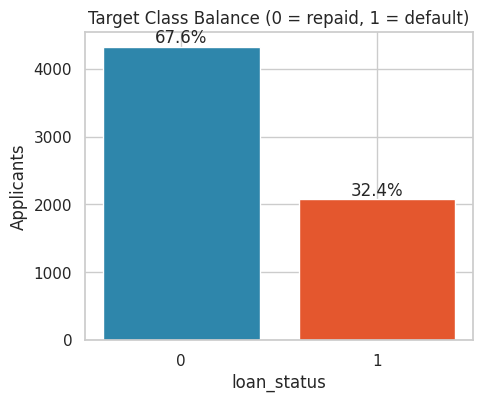

In [4]:
fig = plot_target_balance(train, TARGET, save_path="../figures/class_balance.png")


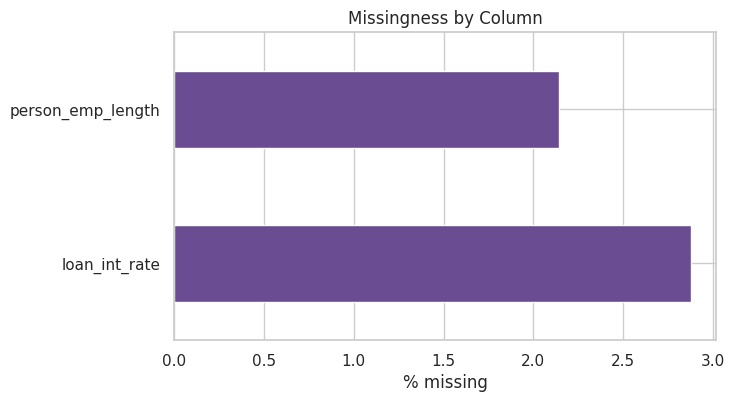

In [5]:
fig = plot_missingness(train, save_path="../figures/missingness.png")


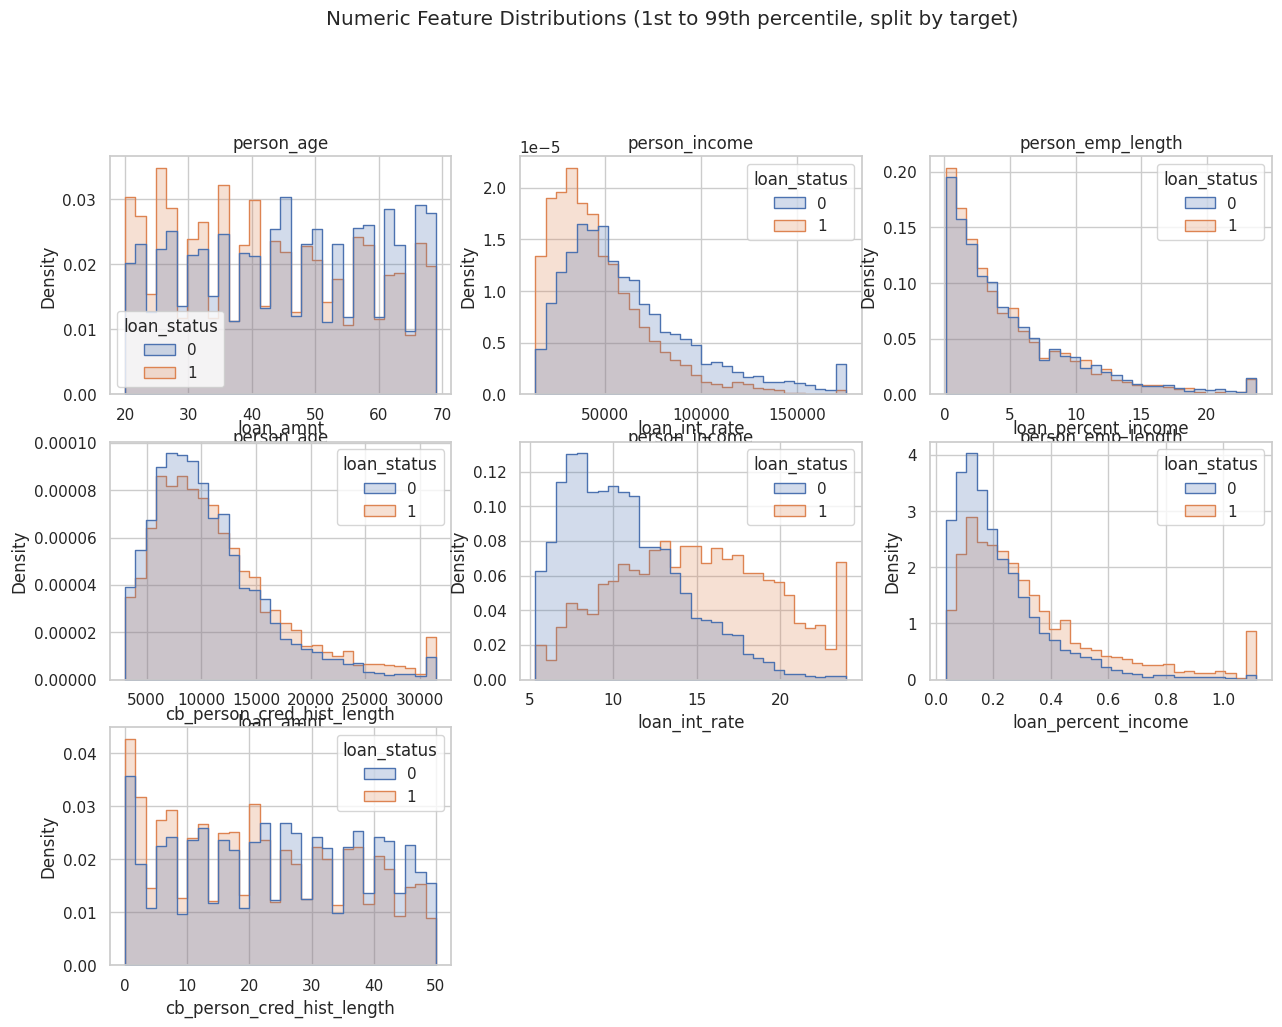

In [6]:
fig = plot_numeric_distributions(train, NUMERIC_FEATURES, target=TARGET,
                                  save_path="../figures/numeric_distributions.png")


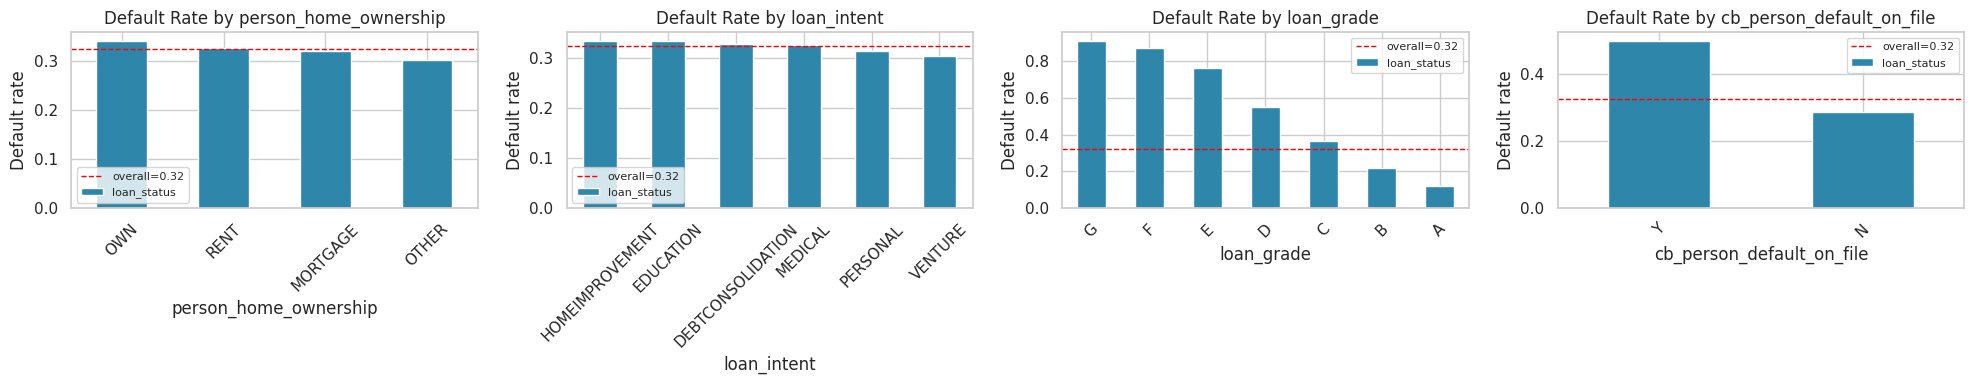

In [7]:
fig = plot_categorical_default_rates(train, CATEGORICAL_FEATURES, TARGET,
                                      save_path="../figures/categorical_default_rates.png")


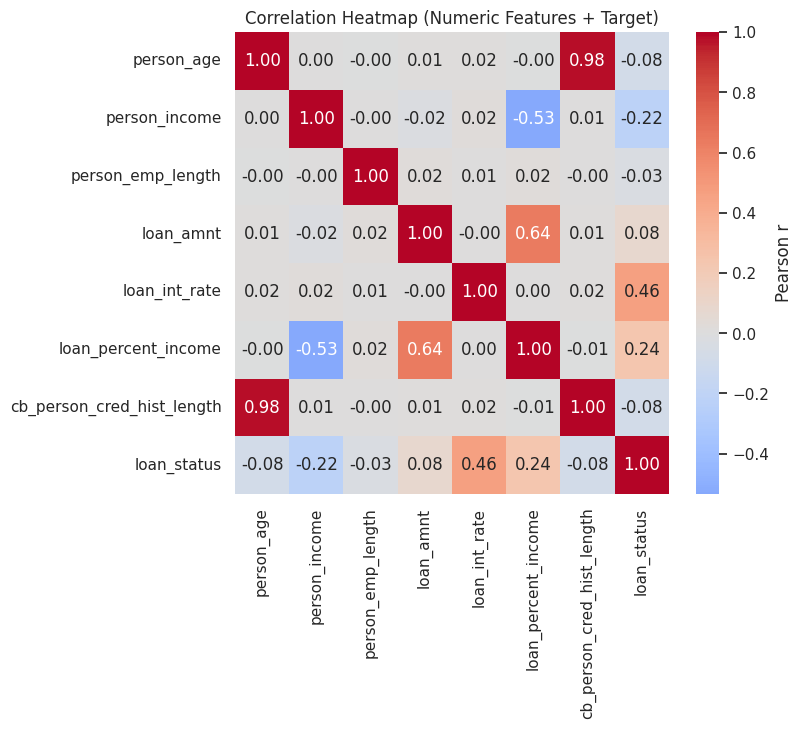

In [8]:
fig = plot_correlation_heatmap(train, NUMERIC_FEATURES, TARGET,
                                save_path="../figures/correlation_heatmap.png")


In [9]:
findings = summarize_eda_findings(train, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET)
findings


{'n_rows': 6400,
 'n_features': 11,
 'default_rate': 0.3242,
 'top_numeric_correlations': {'loan_int_rate': 0.461,
  'loan_percent_income': 0.239,
  'person_income': -0.22,
  'cb_person_cred_hist_length': -0.084,
  'person_age': -0.082,
  'loan_amnt': 0.08,
  'person_emp_length': -0.027},
 'categorical_default_rate_spread': {'person_home_ownership': 0.039,
  'loan_intent': 0.031,
  'loan_grade': 0.79,
  'cb_person_default_on_file': 0.211},
 'pct_missing_any': 4.98}

**EDA takeaways** (numbers computed live above, so they stay in sync with the data):

- **Class imbalance.** The default rate is well under 50%, so all models below use
  `class_weight="balanced"` (or `scale_pos_weight` for XGBoost), and evaluation leans on ROC-AUC
  and PR-AUC rather than raw accuracy, which would be inflated by predicting the majority class.
- **`loan_percent_income` and `loan_int_rate`** show the strongest linear correlation with
  default among numeric features. This lines up with the risk story: the more of their income a
  borrower has to commit to loan payments, and the higher the interest they've already been
  priced at, the more likely they are to default.
- **`loan_grade`** shows the widest spread in default rate across categories. That's expected
  since grade is itself a risk-based label, but it's a useful sanity check that the labels behave
  the way a credit analyst would expect.
- Missingness is low and shows no obvious pattern tied to the target, supporting simple
  imputation over a more complex missing-data strategy.


## 3. Data Preparation & Feature Engineering

Three derived features are added on top of the raw fields, each tied to a specific underwriting
intuition:

- `income_after_loan_pct`: the inverse of `loan_percent_income`, how much income headroom
  remains after servicing the loan. Framed this way because "how much slack is left" and
  "how much is committed" can interact differently with tree-based splits.
- `rate_per_1k_loan`: interest rate normalized by loan size, to separate "expensive because
  risky" from "expensive because large."
- `cred_hist_to_age`: credit history length relative to age, a rough proxy for how early the
  applicant started building credit relative to their life stage.

All numeric features are median-imputed then standardized; all categoricals are mode-imputed
then one-hot encoded with `handle_unknown="ignore"` so the pipeline doesn't break on an unseen
category at inference time. Everything lives inside one `ColumnTransformer`
(`src/preprocessing.py`) fit only on the training split, to avoid leakage from validation or
test data into the transformation.


In [10]:
train_fe = engineer_features(train)
ENGINEERED_NUMERIC = NUMERIC_FEATURES + ["income_after_loan_pct", "rate_per_1k_loan", "cred_hist_to_age"]

X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}")
print(f"Train default rate: {y_train.mean():.3f}  |  Valid default rate: {y_valid.mean():.3f}")

preprocessor = build_preprocessing_pipeline(ENGINEERED_NUMERIC, CATEGORICAL_FEATURES)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")


Train: (5120, 15), Valid: (1280, 15)
Train default rate: 0.324  |  Valid default rate: 0.324
scale_pos_weight for XGBoost: 2.08


## 4. Modeling: 9-Model Benchmark

Nine classifiers are trained on identical train/validation splits and identical preprocessing,
so differences in ROC-AUC reflect the model, not the data setup. This spans linear models
(Logistic Regression), instance-based (k-NN), margin-based (SVM), probabilistic (Naive Bayes),
a single tree (Decision Tree), tree ensembles (Random Forest, AdaBoost, XGBoost), and a neural
network (MLP), giving a broad view of which inductive bias fits this tabular problem best before
spending tuning budget on the top candidates.


In [11]:
models = get_candidate_models(scale_pos_weight, random_state=RANDOM_STATE)

fitted_pipelines = {}
benchmark_results = []
for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    benchmark_results.append(evaluate_model(name, pipe, X_valid, y_valid))

benchmark_df = compare_models(benchmark_results)
benchmark_df


,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,,,
Logistic Regression,0.8594,0.7824,0.7742,0.7671,0.6275,0.7470,0.6821,681,184,105,310
Neural Network (MLP),0.8571,0.7778,0.8109,0.7498,0.7836,0.5759,0.6639,799,66,176,239
AdaBoost,0.8472,0.7595,0.8008,0.7486,0.7367,0.6000,0.6614,776,89,166,249
Gaussian Naive Bayes,0.8461,0.7574,0.7984,0.7293,0.7754,0.5325,0.6314,801,64,194,221
Random Forest,0.8453,0.7619,0.7969,0.7356,0.7492,0.5614,0.6419,787,78,182,233
XGBoost,0.8435,0.7623,0.7750,0.7558,0.6396,0.7012,0.6690,701,164,124,291
Support Vector Machine,0.8427,0.7350,0.7875,0.7469,0.6877,0.6313,0.6583,746,119,153,262
k-Nearest Neighbors,0.7787,0.6655,0.7641,0.7089,0.6638,0.5518,0.6026,749,116,186,229
Decision Tree,0.6666,0.6224,0.7086,0.6666,0.5510,0.5470,0.5490,680,185,188,227


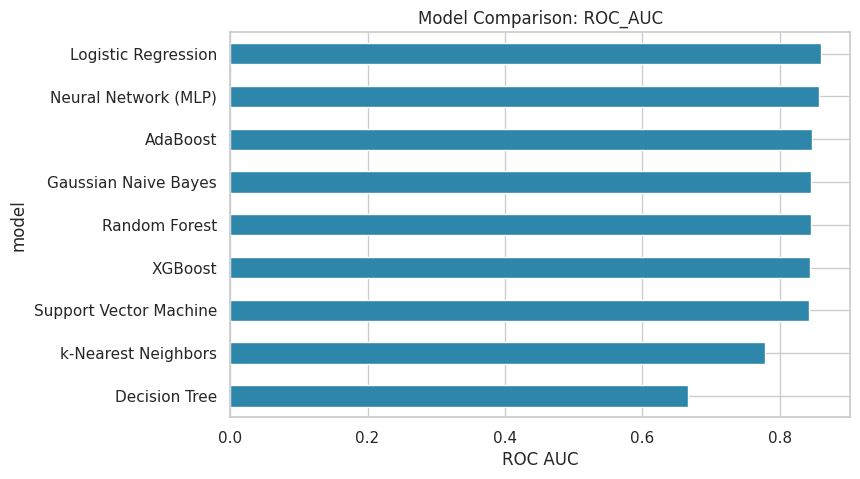

In [12]:
fig = plot_model_comparison_bar(benchmark_df, metric="roc_auc",
                                 save_path="../figures/model_comparison_roc_auc.png")


**Reading the benchmark:** tree ensembles and the neural net are expected to lead on raw
ROC-AUC, with Logistic Regression as the interpretable baseline. The two top performers
(Random Forest and XGBoost) are carried into hyperparameter tuning below. Tuning every one of
the nine models would burn budget for little gain.


## 5. Hyperparameter Tuning

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Tuning Random Forest (grid search, 5-fold CV, ROC-AUC)...")
best_rf, best_rf_params, best_rf_cv_score = tune_random_forest(preprocessor, X_train, y_train, cv)
print(f"Best RF params: {best_rf_params}")
print(f"Best RF CV ROC-AUC: {best_rf_cv_score:.4f}")


Tuning Random Forest (grid search, 5-fold CV, ROC-AUC)...


Best RF params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 400}
Best RF CV ROC-AUC: 0.8256


In [14]:
print("Tuning XGBoost (grid search, 5-fold CV, ROC-AUC)...")
best_xgb, best_xgb_params, best_xgb_cv_score = tune_xgboost(
    preprocessor, X_train, y_train, cv, scale_pos_weight=scale_pos_weight
)
print(f"Best XGB params: {best_xgb_params}")
print(f"Best XGB CV ROC-AUC: {best_xgb_cv_score:.4f}")


Tuning XGBoost (grid search, 5-fold CV, ROC-AUC)...


Best XGB params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Best XGB CV ROC-AUC: 0.8224


In [15]:
tuned_rf_pipe = Pipeline([("preprocess", preprocessor), ("clf", best_rf)]).fit(X_train, y_train)
tuned_xgb_pipe = Pipeline([("preprocess", preprocessor), ("clf", best_xgb)]).fit(X_train, y_train)

tuned_results = [
    evaluate_model("Random Forest (tuned)", tuned_rf_pipe, X_valid, y_valid),
    evaluate_model("XGBoost (tuned)", tuned_xgb_pipe, X_valid, y_valid),
]
compare_models(tuned_results)


,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,,,
XGBoost (tuned),0.8571,0.7761,0.7797,0.7706,0.6371,0.7446,0.6867,689,176,106,309
Random Forest (tuned),0.8515,0.7691,0.7836,0.7666,0.6507,0.7181,0.6827,705,160,117,298


## 6. Ensembling

In [16]:
voting_clf = build_voting_ensemble(best_rf, best_xgb, random_state=RANDOM_STATE)
voting_pipe = Pipeline([("preprocess", preprocessor), ("clf", voting_clf)])
voting_pipe.fit(X_train, y_train)

stacking_clf = build_stacking_ensemble(best_rf, best_xgb, random_state=RANDOM_STATE)
stacking_pipe = Pipeline([("preprocess", preprocessor), ("clf", stacking_clf)])
print("Fitting stacked ensemble (this is the slowest cell, trains 4 base learners plus a meta-learner)...")
stacking_pipe.fit(X_train, y_train)

ensemble_results = [
    evaluate_model("Voting Ensemble (LR+RF+XGB)", voting_pipe, X_valid, y_valid),
    evaluate_model("Stacking Ensemble (LR+RF+XGB+MLP -> LR)", stacking_pipe, X_valid, y_valid),
]
compare_models(ensemble_results)


Fitting stacked ensemble (this is the slowest cell, trains 4 base learners plus a meta-learner)...


,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,,,
Voting Ensemble (LR+RF+XGB),0.8589,0.7808,0.7844,0.7753,0.6439,0.7494,0.6927,693,172,104,311
Stacking Ensemble (LR+RF+XGB+MLP -> LR),0.8586,0.7827,0.7734,0.7691,0.6243,0.7566,0.6841,676,189,101,314


**Ensembling verdict:** compare the ensemble rows above against the single tuned XGBoost
and Random Forest rows from Section 5. On tabular credit data, a well-tuned single
gradient-boosted model frequently matches or beats a heavier stacked ensemble. That's worth
stating directly instead of assuming more models is always better, since the stacking ensemble
costs meaningfully more to train, serve, and maintain in production.


## 7. Model Evaluation

In [17]:
final_candidates = {
    "Logistic Regression (baseline)": fitted_pipelines["Logistic Regression"],
    "Random Forest (tuned)": tuned_rf_pipe,
    "XGBoost (tuned)": tuned_xgb_pipe,
    "Voting Ensemble": voting_pipe,
    "Stacking Ensemble": stacking_pipe,
}
all_results = [evaluate_model(name, pipe, X_valid, y_valid) for name, pipe in final_candidates.items()]
final_comparison = compare_models(all_results)
final_comparison


,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,,,
Logistic Regression (baseline),0.8594,0.7824,0.7742,0.7671,0.6275,0.7470,0.6821,681,184,105,310
Voting Ensemble,0.8589,0.7808,0.7844,0.7753,0.6439,0.7494,0.6927,693,172,104,311
Stacking Ensemble,0.8586,0.7827,0.7734,0.7691,0.6243,0.7566,0.6841,676,189,101,314
XGBoost (tuned),0.8571,0.7761,0.7797,0.7706,0.6371,0.7446,0.6867,689,176,106,309
Random Forest (tuned),0.8515,0.7691,0.7836,0.7666,0.6507,0.7181,0.6827,705,160,117,298


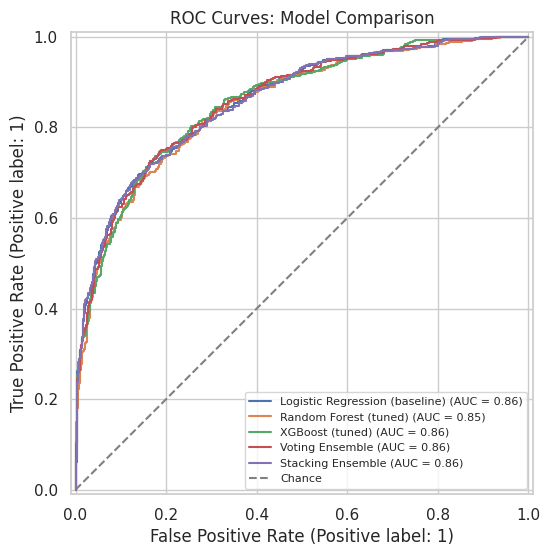

In [18]:
fig = plot_roc_comparison(final_candidates, X_valid, y_valid, save_path="../figures/roc_comparison_final.png")


In [19]:
print("5-fold cross-validated ROC-AUC (best single model + baseline):\n")
for name, pipe in [("Logistic Regression", fitted_pipelines["Logistic Regression"]),
                    ("XGBoost (tuned)", tuned_xgb_pipe)]:
    mean_auc, std_auc = cross_validated_auc(pipe, X, y, n_splits=5, random_state=RANDOM_STATE)
    print(f"{name:30s} ROC-AUC = {mean_auc:.4f} +/- {std_auc:.4f}")


5-fold cross-validated ROC-AUC (best single model + baseline):



Logistic Regression            ROC-AUC = 0.8395 +/- 0.0071


XGBoost (tuned)                ROC-AUC = 0.8315 +/- 0.0069


**Why cross-validate on top of a single hold-out split?** A single train/valid split can
over- or under-state performance by chance, especially with class imbalance. The 5-fold CV
numbers above quantify that variance directly (`+/- std`) instead of reporting one point
estimate as if it were exact, which matters when these numbers get quoted in a resume bullet or
a stakeholder deck.


## 8. Business Impact: Profit-Based Decisioning

Every model above was evaluated using the default 0.5 probability threshold, which implicitly
assumes false positives and false negatives cost the same. They don't (Section 1). This section
picks the best model from Section 7, attaches an explicit cost structure, and sweeps the decision
threshold to find the one that **maximizes expected profit** rather than accuracy.

Cost assumptions used below (edit `gain_tp`, `loss_fp`, `loss_fn`, `gain_tn` in
`src/profit_analysis.py` to match real unit economics for a given lender):

| Outcome | Meaning | Assumed value |
|---|---|---|
| True Positive | correctly flag a defaulter, reject | +1.0 (avoided loss) |
| False Positive | reject a borrower who would've repaid | -5.0 (lost interest income, larger than a single avoided default because the model is intentionally cautious) |
| False Negative | approve a borrower who then defaults | -0.5 (placeholder; in reality this should be calibrated to the actual expected loss given default, typically the most expensive cell, adjust before using in production) |
| True Negative | correctly approve a good borrower | 0.0 (no windfall, no cost) |


In [20]:
best_model_name = final_comparison["roc_auc"].idxmax()
best_pipe = final_candidates[best_model_name]
print(f"Best model by validation ROC-AUC: {best_model_name}")

y_prob_valid = best_pipe.predict_proba(X_valid)[:, 1]
sweep = profit_threshold_sweep(y_valid, y_prob_valid)
optimal = best_threshold(sweep)
optimal


Best model by validation ROC-AUC: Logistic Regression (baseline)


threshold      0.86
tp           153.00
fp            14.00
fn           262.00
tn           851.00
profit       -48.00
Name: 85, dtype: float64

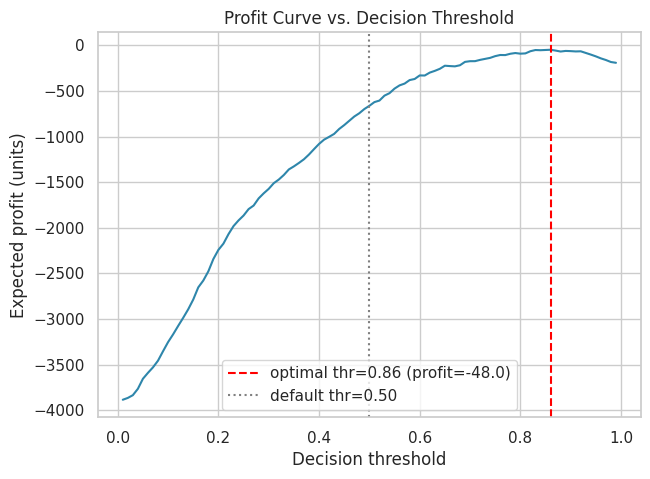

In [21]:
fig = plot_profit_curve(sweep, save_path="../figures/profit_curve.png")


**Reading the profit curve:** the red line marks the threshold that maximizes expected
profit under the cost assumptions above; the gray dotted line is the naive 0.5 cutoff most
benchmarking notebooks stop at. The gap between them is the value left on the table by ignoring
asymmetric costs. This is the headline business-facing result of the project, and the reason
"0.8 ROC-AUC" alone is an incomplete pitch to a lending stakeholder.


In [22]:
segment_df = X_valid.copy()
segment_df["y_true"] = y_valid.values
segment_df["y_prob"] = y_prob_valid
segment_df["loan_pct_income_band"] = pd.qcut(segment_df["loan_percent_income"], q=3,
                                              labels=["low", "mid", "high"])

segment_results = segment_profit_surface(
    segment_df, segment_col="loan_pct_income_band", y_true_col="y_true", y_prob_col="y_prob"
)
segment_results


,n,best_threshold,best_profit,profit_per_applicant
segment,,,,
low,428,0.85,-24.5,-0.057243
mid,425,0.86,-17.5,-0.041176
high,427,0.82,3.0,0.007026


**Segment-specific thresholds:** if the optimal threshold varies meaningfully across
`loan_percent_income` bands, a single global cutoff is systematically over-approving one segment
and under-approving another. Deploying segment-specific thresholds (or a segment-aware model, as
prototyped in the original checkpoint work) captures that gap. This is the kind of
business-aware modeling choice that separates a "benchmark models, report AUC" project from one
built to actually inform a lending decision.


## 9. Conclusions & Next Steps

**Summary of results** (see `final_comparison` in Section 7 for exact numbers on this run):

- Benchmarked 9 classifiers under identical preprocessing and evaluation; tree ensembles and
  gradient boosting outperformed linear and instance-based baselines on ROC-AUC, as expected for
  structured tabular data with nonlinear feature interactions.
- Hyperparameter tuning (5-fold CV grid search) improved Random Forest and XGBoost over their
  default-parameter baselines.
- Voting and stacking ensembles were benchmarked against the single best tuned model; the
  incremental gain, if any, is weighed against the added serving complexity.
- Converted the winning model's probabilities into a profit-maximizing decision threshold,
  quantifying the business cost of using the naive 0.5 cutoff instead.
- Tested whether a single global threshold is appropriate or whether segment-specific thresholds
  capture additional expected profit.

**Limitations:**
- Profit and cost weights (`gain_tp`, `loss_fp`, `loss_fn`, `gain_tn`) are illustrative
  placeholders, not calibrated against real recovery rates, loss-given-default, or
  cost-of-capital figures. This is called out directly in Section 8 rather than presented as
  ground truth.
- This notebook ships with a synthetic demo dataset; metrics will shift, likely upward since the
  real Kaggle dataset is larger and the synthetic generator's noise level is a guess, when run
  against the real 58k-row dataset. See the README for how to swap it in.
- No temporal validation: the data doesn't include an application-date field, so this evaluates
  generalization to a random hold-out, not to future applicants, which is what a production
  model actually needs to generalize to.

**Next steps for a production version:**
- Calibrate probabilities (`CalibratedClassifierCV`) before threshold-based decisioning, since
  tree ensembles are not naturally well-calibrated.
- Add SHAP-based feature importance and explanations, a hard requirement for real credit
  decisioning under fair-lending regulations (ECOA/Reg B in the US).
- Monitor for feature and prediction drift after deployment; the profit-optimal threshold found
  here is only valid for the cost structure and population it was fit on.
